In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv
/kaggle/input/datasets/kanchandalal123/mcq-ranking-train-dataset-2/ranking_train (1).csv


## this notebook include the code for the BiLSTM as scratch dl model 

In [2]:

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import wandb


SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


wandb.init(
    project="24f1002360-t22026",
    name="bilstm_scratch_model",
    config={
        "architecture": "BiLSTM",
        "embedding_dim": 128,
        "hidden_dim": 256,
        "num_layers": 2,
        "dropout": 0.3,
        "batch_size": 32,
        "epochs": 10,
        "learning_rate": 1e-3,
        "optimizer": "AdamW",
        "max_length": 256
    }
)

config = wandb.config



train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")

print(train.shape)
train.head()

Device: cuda


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 24f1002360 (24f1002360-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


(2000, 8)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [3]:

def create_ranking_dataset(df):

    rows = []

    option_columns = ["A", "B", "C", "D", "E"]

    for _, row in tqdm(df.iterrows(), total=len(df)):

        for option in option_columns:

            rows.append({
                   "question_id": row["id"],
                   "option": option,
                   "text": "Question: " + str(row["prompt"]) + " [SEP] Option: " + str(row[option]),
                   "label": int(option == row["answer"])
              })

    return pd.DataFrame(rows)


ranking_df = create_ranking_dataset(train)

print(ranking_df.shape)

ranking_df.head()

  0%|          | 0/2000 [00:00<?, ?it/s]

(10000, 4)


,question_id,option,text,label
0,1,A,Question: Pick the best possible answer: What ...,0
1,1,B,Question: Pick the best possible answer: What ...,1
2,1,C,Question: Pick the best possible answer: What ...,0
3,1,D,Question: Pick the best possible answer: What ...,0
4,1,E,Question: Pick the best possible answer: What ...,0


In [4]:
print(ranking_df["label"].value_counts())

ranking_df["label"].value_counts(normalize=True)

label
0    8000
1    2000
Name: count, dtype: int64


label
0    0.8
1    0.2
Name: proportion, dtype: float64

In [5]:

splitter = GroupShuffleSplit(
    test_size=0.2,
    random_state=SEED
)

train_idx, val_idx = next(
    splitter.split(
        ranking_df,
        groups=ranking_df["question_id"]
    )
)

train_df = ranking_df.iloc[train_idx].reset_index(drop=True)

val_df = ranking_df.iloc[val_idx].reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (8000, 4)
Validation: (2000, 4)


In [6]:
train_df.to_csv("bilstm_train.csv", index=False)
val_df.to_csv("bilstm_val.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


In [7]:
import re
from collections import Counter

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

MAX_LEN = 256


def tokenize(text):
    """
    Simple tokenizer built from scratch.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text.split()

In [8]:
counter = Counter()

for text in tqdm(train_df["text"]):

    tokens = tokenize(text)

    counter.update(tokens)

MIN_FREQ = 2

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, freq in counter.items():

    if freq >= MIN_FREQ:

        vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

  0%|          | 0/8000 [00:00<?, ?it/s]

Vocabulary Size: 2970


In [9]:

def encode_text(text):

    tokens = tokenize(text)

    ids = [
        vocab.get(token, vocab[UNK_TOKEN])
        for token in tokens
    ]

    if len(ids) > MAX_LEN:
        ids = ids[:MAX_LEN]

    else:
        ids += [vocab[PAD_TOKEN]] * (MAX_LEN - len(ids))

    return ids

In [10]:
sample = train_df.iloc[0]["text"]

print(sample)

encoded = encode_text(sample)

print(encoded[:30])

print(len(encoded))

Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. [SEP] Option: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 4, 15, 16, 17, 18, 19, 20, 21, 4, 22, 23, 24, 25, 10, 11, 26, 27]
256


In [11]:
class MCQDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()
        self.question_ids = dataframe["question_id"].tolist()
        self.options = dataframe["option"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = torch.tensor(
            encode_text(self.texts[idx]),
            dtype=torch.long
        )

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return (
            text,
            label,
            self.question_ids[idx],
            self.options[idx]
        )

In [12]:
train_dataset = MCQDataset(train_df)

val_dataset = MCQDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 250
Validation batches: 63


In [13]:
batch = next(iter(train_loader))

texts, labels, question_ids, options = batch

print("Input Shape :", texts.shape)
print("Labels Shape:", labels.shape)

print("Question IDs:", question_ids[:5])

print("Options:", options[:5])

Input Shape : torch.Size([32, 256])
Labels Shape: torch.Size([32])
Question IDs: tensor([1258,  946, 1459,   76, 1993])
Options: ('D', 'B', 'E', 'A', 'C')


In [14]:
class BiLSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout
    ):
        super().__init__()


        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim * 2,
            2
        )

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.bilstm(x)

  
        hidden_state = torch.mean(output, dim=1)

        hidden_state = self.dropout(hidden_state)

        logits = self.fc(hidden_state)

        return logits

In [15]:

VOCAB_SIZE = len(vocab)

model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=config.embedding_dim,
    hidden_dim=config.hidden_dim,
    num_layers=config.num_layers,
    dropout=config.dropout
)

model = model.to(device)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(2970, 128, padding_idx=0)
  (bilstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)


In [16]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 2,748,674
Trainable Parameters: 2,748,674


In [17]:

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [18]:

batch_inputs, batch_labels, batch_question_ids, batch_options = next(iter(train_loader))

batch_inputs = batch_inputs.to(device)

outputs = model(batch_inputs)

print("Output Shape:", outputs.shape)
print("Batch Size:", batch_inputs.shape[0])

Output Shape: torch.Size([32, 2])
Batch Size: 32


In [19]:
print("=" * 60)
print("BiLSTM Scratch Model")
print("=" * 60)

print(f"Vocabulary Size : {VOCAB_SIZE}")
print(f"Embedding Dim   : {config.embedding_dim}")
print(f"Hidden Dim      : {config.hidden_dim}")
print(f"LSTM Layers     : {config.num_layers}")
print(f"Dropout         : {config.dropout}")
print(f"Learning Rate   : {config.learning_rate}")
print(f"Batch Size      : {config.batch_size}")
print(f"Epochs          : {config.epochs}")
print("=" * 60)

BiLSTM Scratch Model
Vocabulary Size : 2970
Embedding Dim   : 128
Hidden Dim      : 256
LSTM Layers     : 2
Dropout         : 0.3
Learning Rate   : 0.001
Batch Size      : 32
Epochs          : 10


In [20]:
def apk(actual, predicted, k=3):

    if len(predicted) > k:
        predicted = predicted[:k]

    score = 0.0
    hits = 0.0

    for i, p in enumerate(predicted):

        if p == actual and p not in predicted[:i]:

            hits += 1.0
            score += hits / (i + 1.0)

    return score


def mapk(actuals, predictions, k=3):

    return np.mean([
        apk(a, p, k)
        for a, p in zip(actuals, predictions)
    ])

In [21]:
bad_groups = []

for qid, group in val_df.groupby("question_id"):

    positives = group["label"].sum()

    if positives != 1:
        bad_groups.append((qid, positives))

print("Bad groups:", len(bad_groups))

if bad_groups:
    print(bad_groups[:10])

Bad groups: 0


In [22]:

def train_one_epoch(model, loader):

    model.train()

    total_loss = 0

    predictions = []

    labels = []

    for inputs, targets, question_ids, options in tqdm(loader):

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
             model.parameters(),
             max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())

        labels.extend(targets.cpu().numpy())

    loss = total_loss / len(loader)

    acc = accuracy_score(labels, predictions)

    f1 = f1_score(labels, predictions)

    return loss, acc, f1

In [23]:
def evaluate(model, loader):

    model.eval()

    total_loss = 0

    predictions = []
    labels = []

    with torch.no_grad():

        for inputs, targets, _, _ in loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, targets)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())
            labels.extend(targets.cpu().numpy())

    loss = total_loss / len(loader)

    acc = accuracy_score(labels, predictions)

    f1 = f1_score(labels, predictions)

    return loss, acc, f1

In [24]:


for epoch in range(config.epochs):

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, val_f1 = evaluate(
        model,
        val_loader
    )

    scheduler.step(val_f1)

    wandb.log({

    "epoch": epoch + 1,

    "train_loss": train_loss,
    "validation_loss": val_loss,

    "train_accuracy": train_acc,
    "validation_accuracy": val_acc,

    "train_f1": train_f1,
    "validation_f1": val_f1,

    "learning_rate":
    optimizer.param_groups[0]["lr"]

})

    print()

    print(f"Epoch {epoch+1}/{config.epochs}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Train F1   : {train_f1:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Val F1     : {val_f1:.4f}")


    print("-" * 60)

    best_f1 = 0

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(
            model.state_dict(),
           "best_bilstm_model.pt"
        )

        wandb.save("best_bilstm_model.pt")

  0%|          | 0/250 [00:00<?, ?it/s]


Epoch 1/10
Train Loss : 0.5093
Train Acc  : 0.7955
Train F1   : 0.0285
Val Loss   : 0.4766
Val Acc    : 0.8000
Val F1     : 0.0000
------------------------------------------------------------


  0%|          | 0/250 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.



Epoch 2/10
Train Loss : 0.4728
Train Acc  : 0.8060
Train F1   : 0.2631
Val Loss   : 0.3980
Val Acc    : 0.8595
Val F1     : 0.5460
------------------------------------------------------------


...


Epoch 8/10
Train Loss : 0.1670
Train Acc  : 0.9317
Train F1   : 0.8162
Val Loss   : 0.1504
Val Acc    : 0.9365
Val F1     : 0.8390
------------------------------------------------------------


  0%|          | 0/250 [00:00<?, ?it/s]


Epoch 9/10
Train Loss : 0.1255
Train Acc  : 0.9470
Train F1   : 0.8607
Val Loss   : 0.1362
Val Acc    : 0.9525
Val F1     : 0.8787
------------------------------------------------------------


  0%|          | 0/250 [00:00<?, ?it/s]


Epoch 10/10
Train Loss : 0.0982
Train Acc  : 0.9625
Train F1   : 0.9032
Val Loss   : 0.0901
Val Acc    : 0.9650
Val F1     : 0.9062
------------------------------------------------------------


In [25]:
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▁▄▅▅▅▆▇▇█
train_f1,▁▃▅▆▆▆▇▇██
train_loss,█▇▆▅▅▄▃▂▁▁
validation_accuracy,▁▄▄▄▅▅▆▇▇█
validation_f1,▁▅▅▅▆▇▇▇██
validation_loss,█▇▆▅▅▄▃▂▂▁
epoch,10
learning_rate,0.001
train_accuracy,0.9625


In [26]:

model.load_state_dict(
    torch.load(
        "best_bilstm_model.pt",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [27]:

all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():

    for inputs, targets, _, _ in val_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        probabilities = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probabilities, dim=1)

        all_predictions.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            targets.numpy()
        )

        all_probabilities.extend(
            probabilities[:,1].cpu().numpy()
        )

In [28]:

print(classification_report(
    all_labels,
    all_predictions,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9625    0.9950    0.9785      1600
           1     0.9769    0.8450    0.9062       400

    accuracy                         0.9650      2000
   macro avg     0.9697    0.9200    0.9423      2000
weighted avg     0.9654    0.9650    0.9640      2000



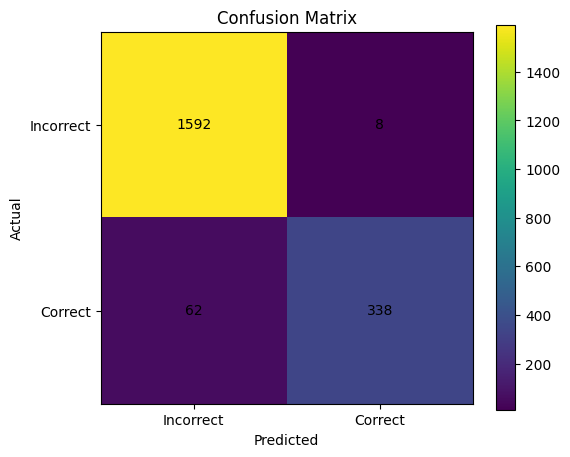

In [31]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)
import matplotlib.pyplot as plt
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Incorrect","Correct"])

plt.yticks([0,1],["Incorrect","Correct"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.show()

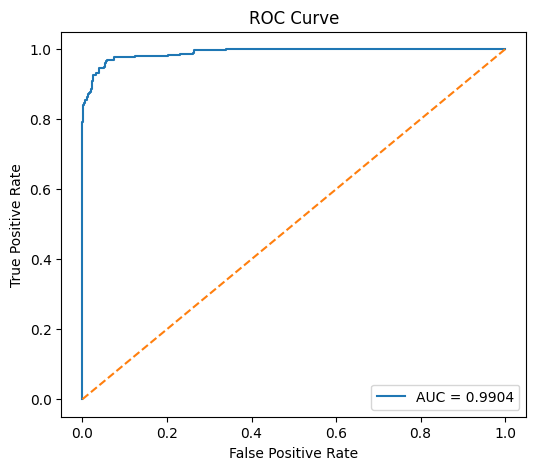

In [32]:
fpr, tpr, _ = roc_curve(
    all_labels,
    all_probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

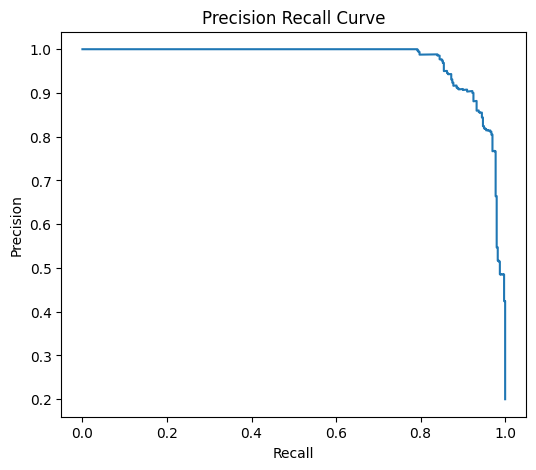

In [33]:
precision, recall, _ = precision_recall_curve(
    all_labels,
    all_probabilities
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [35]:

torch.save(
    model.state_dict(),
    "bilstm_final_model.pt"
)

print("Final model saved successfully.")

Final model saved successfully.


In [37]:
test = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
)

print(test.shape)

test.head()

(500, 7)


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [38]:
def create_test_ranking_dataset(df):

    rows = []

    for _, row in df.iterrows():

        for option in ["A", "B", "C", "D", "E"]:

            rows.append({

                "question_id": row["id"],

                "option": option,

                "text":
                    "Question: "
                    + str(row["prompt"])
                    + " [SEP] Option: "
                    + str(row[option])

            })

    return pd.DataFrame(rows)


ranking_test = create_test_ranking_dataset(test)

print(ranking_test.shape)

ranking_test.head()

(2500, 3)


,question_id,option,text
0,1,A,Question: Pick the best possible answer: What ...
1,1,B,Question: Pick the best possible answer: What ...
2,1,C,Question: Pick the best possible answer: What ...
3,1,D,Question: Pick the best possible answer: What ...
4,1,E,Question: Pick the best possible answer: What ...


In [39]:
class TestDataset(Dataset):

    def __init__(self, dataframe):

        self.question_ids = dataframe["question_id"].tolist()

        self.options = dataframe["option"].tolist()

        self.texts = dataframe["text"].tolist()

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        return (

            torch.tensor(
                encode_text(self.texts[idx]),
                dtype=torch.long
            ),

            self.question_ids[idx],

            self.options[idx]

        )

In [40]:
test_dataset = TestDataset(ranking_test)

test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False

)

In [46]:
vocab_size = len(vocab)

model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.3
).to(device)

model.load_state_dict(
    torch.load(
        "best_bilstm_model.pt",
        map_location=device
    )
)

model.eval()

print("BiLSTM model loaded successfully!")

BiLSTM model loaded successfully!


In [51]:
results = []

with torch.no_grad():

    for inputs, question_ids, options in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        probs = torch.softmax(outputs, dim=1)[:,1]

        probs = probs.cpu().numpy()

        for qid, option, prob in zip(

            question_ids,

            options,

            probs

        ):

            results.append({
                "id": int(qid),
                "option": option,
                "score": float(prob)
          })

results = pd.DataFrame(results)

results.head()

,id,option,score
0,1,A,0.502510
1,1,B,0.006584
2,1,C,0.008187
3,1,D,0.007949
4,1,E,0.005307


In [52]:
submission = []

for question_id, group in results.groupby("id"):

    prediction = (

        group

        .sort_values(

            "score",

            ascending=False

        )

        ["option"]

        .tolist()

    )

    submission.append({

        "id": question_id,

        "prediction": " ".join(prediction[:3])

    })

submission = pd.DataFrame(submission)

submission.head()

,id,prediction
0,1,A C D
1,2,B E D
2,3,B E D
3,4,E C A
4,5,C A E


In [53]:
submission.to_csv(

    "submission.csv",

    index=False

)

print("Submission Saved")

submission.head(10)

Submission Saved


,id,prediction
0,1,A C D
1,2,B E D
2,3,B E D
3,4,E C A
4,5,C A E
5,6,D A E
6,7,E D A
7,8,B E A
8,9,C D A
9,10,B A E


In [50]:
submission = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"
)

print(submission.shape)

submission.head()

(500, 2)


,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C
